In [1]:
###pip install shap

In [2]:
###pip install imbalanced-learn

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import time
import numpy as np

import encode
import quanqual
import EDA
import EDA1
import Capstone1_RandomForest
import deploy


from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import importlib



In [4]:
st_habits = pd.read_csv('student_habits.csv')         # raw data

st_habits1 = st_habits.copy()

st_habits1


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


In [5]:
st_habits1 = encode.data_rename(st_habits1)

In [6]:
st_habits1 = encode.data_encoding(st_habits1)

In [7]:
st_habits1

,age,study_hrs,part_time_job,media_hrs,att_percent,sleep_hrs,diet_quality,exercise_fq,internet_quality,mental_health_rating,extracurricular,exam_score,gender_Female,gender_Male,gender_Other,par_edu_Bachelor,par_edu_High School,par_edu_Master,par_edu_Unknown
0,23,0.0,0,2.3,85.0,8.0,1,6,1,8,1,56.2,1,0,0,0,0,1,0
1,20,6.9,0,5.1,97.3,4.6,2,6,1,8,0,100.0,1,0,0,0,1,0,0
2,21,1.4,0,4.4,94.8,8.0,0,1,0,1,0,34.3,0,1,0,0,1,0,0
3,23,1.0,0,4.9,71.0,9.2,0,4,2,1,1,26.8,1,0,0,0,0,1,0
4,19,5.0,0,4.9,90.9,4.9,1,3,2,1,0,66.4,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,21,2.6,0,2.1,77.0,7.5,1,2,2,6,1,76.1,1,0,0,0,1,0,0
996,17,2.9,1,3.4,86.0,6.8,0,1,1,6,1,65.9,1,0,0,0,1,0,0
997,20,3.0,0,3.9,61.9,6.5,2,5,2,9,1,64.4,0,1,0,1,0,0,0
998,24,5.4,1,5.2,100.0,7.6,1,0,1,1,0,69.7,0,1,0,1,0,0,0


In [8]:
st_habits1['mental_health_warning'] = (st_habits1['mental_health_rating'] >= 3).astype(int)

### Defining the target variable : Mental health warning : Rating < 3 high risk 

st_habits1


,age,study_hrs,part_time_job,media_hrs,att_percent,sleep_hrs,diet_quality,exercise_fq,internet_quality,mental_health_rating,extracurricular,exam_score,gender_Female,gender_Male,gender_Other,par_edu_Bachelor,par_edu_High School,par_edu_Master,par_edu_Unknown,mental_health_warning
0,23,0.0,0,2.3,85.0,8.0,1,6,1,8,1,56.2,1,0,0,0,0,1,0,1
1,20,6.9,0,5.1,97.3,4.6,2,6,1,8,0,100.0,1,0,0,0,1,0,0,1
2,21,1.4,0,4.4,94.8,8.0,0,1,0,1,0,34.3,0,1,0,0,1,0,0,0
3,23,1.0,0,4.9,71.0,9.2,0,4,2,1,1,26.8,1,0,0,0,0,1,0,0
4,19,5.0,0,4.9,90.9,4.9,1,3,2,1,0,66.4,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,21,2.6,0,2.1,77.0,7.5,1,2,2,6,1,76.1,1,0,0,0,1,0,0,1
996,17,2.9,1,3.4,86.0,6.8,0,1,1,6,1,65.9,1,0,0,0,1,0,0,1
997,20,3.0,0,3.9,61.9,6.5,2,5,2,9,1,64.4,0,1,0,1,0,0,0,1
998,24,5.4,1,5.2,100.0,7.6,1,0,1,1,0,69.7,0,1,0,1,0,0,0,0


In [9]:

indep_X = st_habits1.drop(columns=['mental_health_rating','mental_health_warning'])

dep_Y = st_habits1['mental_health_warning']


In [10]:
indep_X

,age,study_hrs,part_time_job,media_hrs,att_percent,sleep_hrs,diet_quality,exercise_fq,internet_quality,extracurricular,exam_score,gender_Female,gender_Male,gender_Other,par_edu_Bachelor,par_edu_High School,par_edu_Master,par_edu_Unknown
0,23,0.0,0,2.3,85.0,8.0,1,6,1,1,56.2,1,0,0,0,0,1,0
1,20,6.9,0,5.1,97.3,4.6,2,6,1,0,100.0,1,0,0,0,1,0,0
2,21,1.4,0,4.4,94.8,8.0,0,1,0,0,34.3,0,1,0,0,1,0,0
3,23,1.0,0,4.9,71.0,9.2,0,4,2,1,26.8,1,0,0,0,0,1,0
4,19,5.0,0,4.9,90.9,4.9,1,3,2,0,66.4,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,21,2.6,0,2.1,77.0,7.5,1,2,2,1,76.1,1,0,0,0,1,0,0
996,17,2.9,1,3.4,86.0,6.8,0,1,1,1,65.9,1,0,0,0,1,0,0
997,20,3.0,0,3.9,61.9,6.5,2,5,2,1,64.4,0,1,0,1,0,0,0
998,24,5.4,1,5.2,100.0,7.6,1,0,1,0,69.7,0,1,0,1,0,0,0


In [11]:
indep_X.columns

Index(['age', 'study_hrs', 'part_time_job', 'media_hrs', 'att_percent',
       'sleep_hrs', 'diet_quality', 'exercise_fq', 'internet_quality',
       'extracurricular', 'exam_score', 'gender_Female', 'gender_Male',
       'gender_Other', 'par_edu_Bachelor', 'par_edu_High School',
       'par_edu_Master', 'par_edu_Unknown'],
      dtype='object')

In [12]:
dep_Y

0      1
1      1
2      0
3      0
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: mental_health_warning, Length: 1000, dtype: int64

In [13]:
print(st_habits1['mental_health_warning'].value_counts())

mental_health_warning
1    804
0    196
Name: count, dtype: int64


In [14]:
acclog=[]
accsvml=[]
accsvmnl=[]
accknn=[]
accnav=[]
accdes=[]
accrf=[]

kbest=Capstone1_RandomForest.selectkbest(indep_X,dep_Y,4) 

classifier = Capstone1_RandomForest.split_scalar(indep_X,dep_Y)



In [15]:
X_train, X_test, y_train, y_test = Capstone1_RandomForest.split_scalar(kbest,dep_Y)   


classifier ,Accuracy,report,cm = Capstone1_RandomForest.logistic(X_train,y_train,X_test,y_test)
acclog.append(Accuracy)

classifier ,Accuracy,report,cm  = Capstone1_RandomForest.svm_linear(X_train,y_train,X_test,y_test)
accsvml.append(Accuracy)

classifier ,Accuracy,report,cm  = Capstone1_RandomForest.svm_NL(X_train, y_train,X_test,y_test)
accsvmnl.append(Accuracy)

classifier ,Accuracy,report,cm = Capstone1_RandomForest.Navie(X_train,y_train,X_test,y_test)
accnav.append(Accuracy)

classifier ,Accuracy,report,cm  = Capstone1_RandomForest.knn(X_train,y_train,X_test,y_test)
accknn.append(Accuracy)

classifier ,Accuracy,report,cm = Capstone1_RandomForest.Decision(X_train,y_train,X_test,y_test)
accdes.append(Accuracy)

classifier ,Accuracy,report,cm  = Capstone1_RandomForest.random(X_train,y_train,X_test,y_test)
accrf.append(Accuracy)


result = Capstone1_RandomForest.selectk_Classification(acclog,accsvml,accsvmnl,accknn,accnav,accdes,accrf)



/opt/anaconda3/envs/AIML/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/AIML/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/AIML/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [16]:
result

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
ChiSquare,0.812,0.816,0.816,0.78,0.764,0.688,0.724


In [17]:
selector = SelectKBest(score_func=chi2, k=4)
selector.fit(indep_X, dep_Y)
selected_cols = indep_X.columns[selector.get_support()]
print(selected_cols)


Index(['age', 'extracurricular', 'exam_score', 'par_edu_Master'], dtype='object')


Feature Selection Inference  : Fast model but struggles with continuous and non-linear relationships.Chi2 looks 
at each feature independently against the target which is a disadvantage for specific
behavioural dataset ,where we need a model to capture interactions between features .
    To proceed further , Train a tree based model on all features  as trees naturally 
capture non-linear relationships & interactions effectively.



Before SMOTE: (750, 18) (750,)
After SMOTE:  (1200, 18) (1200,)
Before SMOTE:
 mental_health_warning
1    600
0    150
Name: count, dtype: int64

After SMOTE:
 mental_health_warning
0    600
1    600
Name: count, dtype: int64
0.78
              precision    recall  f1-score   support

           0       0.34      0.22      0.27        46
           1       0.84      0.91      0.87       204

    accuracy                           0.78       250
   macro avg       0.59      0.56      0.57       250
weighted avg       0.75      0.78      0.76       250

Generating SHAP summary plot (global feature impact)...


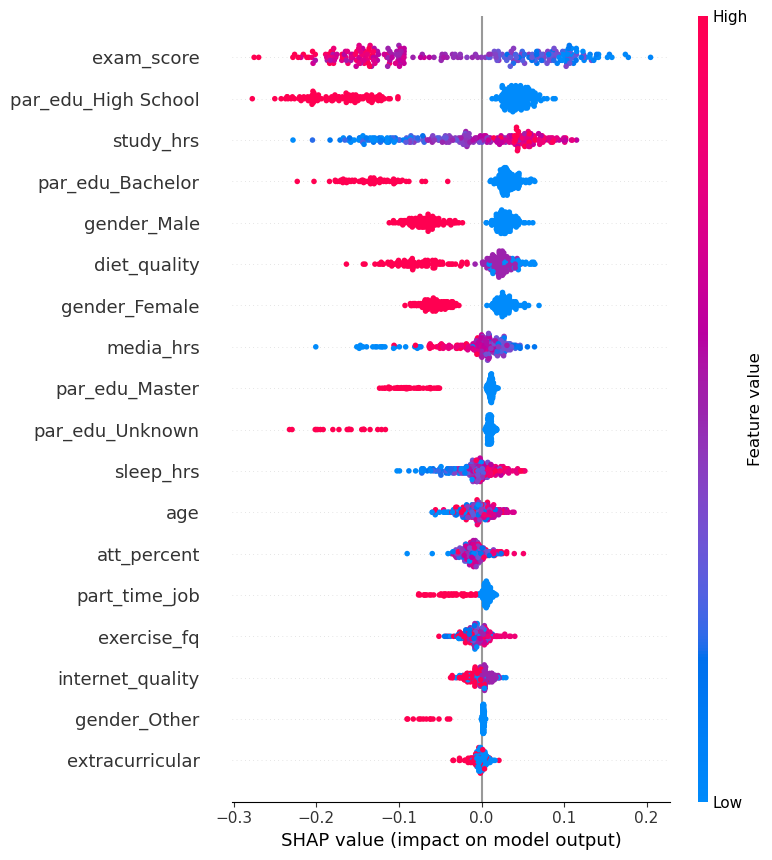


Generating SHAP bar plot (simplified ranking)...


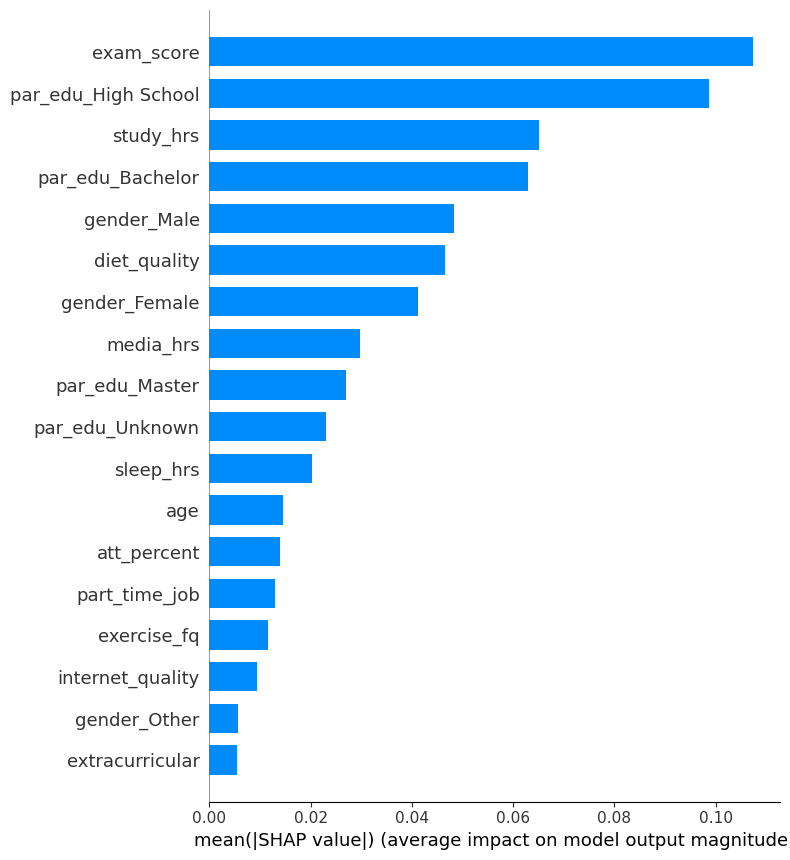


Generating force plot for student at index 0...


In [18]:

indep_X_full = st_habits1.drop(columns=['mental_health_warning', 'mental_health_rating'])
dep_Y = st_habits1['mental_health_warning']

X_train_full, X_test_full, y_train_full, y_test_full = Capstone1_RandomForest.split_unscaled(indep_X_full, dep_Y)

sm = SMOTE(random_state=0)
X_train_full_res, y_train_full_res = sm.fit_resample(X_train_full, y_train_full)

classifier_full, Accuracy_full, report_full, cm_full = Capstone1_RandomForest.random_full(X_train_full_res, y_train_full_res, X_test_full, y_test_full)

print("Before SMOTE:", X_train_full.shape, y_train_full.shape)
print("After SMOTE: ", X_train_full_res.shape, y_train_full_res.shape)

print("Before SMOTE:\n", y_train_full.value_counts())
print("\nAfter SMOTE:\n", y_train_full_res.value_counts())

print(Accuracy_full)
print(report_full)

shap_values, explainer = Capstone1_RandomForest.shap_explain(classifier_full, X_test_full)

In [19]:

pd.crosstab(st_habits1['par_edu_Unknown'], dep_Y, normalize='index')

mental_health_warning,0,1
par_edu_Unknown,,
0,0.199120,0.800880
1,0.164835,0.835165


In [20]:
pd.crosstab(st_habits1['gender_Male'], dep_Y, normalize='index')

mental_health_warning,0,1
gender_Male,,
0,0.198853,0.801147
1,0.192872,0.807128


In [21]:
st_habits1.groupby('mental_health_warning')[['sleep_hrs', 'media_hrs', 'exercise_fq']].mean()

,sleep_hrs,media_hrs,exercise_fq
mental_health_warning,,,
0,6.581122,4.317347,3.010204
1,6.443035,4.327114,3.049751


Model Performance Summary :
    
The Random Forest model trained on all 18 features (post-SMOTE) achieved 78% overall accuracy, 
but this figure is misleading given the class imbalance and the model's actual behavior. 

At-risk class (0) - Recall (0.22) Precision (0.34)  
meaning it correctly identified only about 1 in 5 truly at-risk students, and roughly two-thirds of its at-risk flags were false alarms. 
The not-at-risk class (1) Recall (0.91) Precision (0.84)  which drove the high overall accuracy 
despite the model failing at the task that actually matters for this use case.
    
This gap reflects what the SHAP and crosstab analysis confirmed separately: 
the available features (sleep, media use, exercise, gender, parental education) show negligible separation 
between at-risk and not-at-risk students in this dataset, leaving the model with little genuine signal to learn from. 

The high accuracy is a byproduct of class imbalance rather than evidence of a working early-warning system. 
    
For a counsellor-facing tool where missing an at-risk student carries real cost, 
this recall is not acceptable in its current form, and points to a dataset limitation rather than a modelling or tuning issue.
    

In [22]:
feature_columns = indep_X_full.columns

In [23]:
feature_columns

Index(['age', 'study_hrs', 'part_time_job', 'media_hrs', 'att_percent',
       'sleep_hrs', 'diet_quality', 'exercise_fq', 'internet_quality',
       'extracurricular', 'exam_score', 'gender_Female', 'gender_Male',
       'gender_Other', 'par_edu_Bachelor', 'par_edu_High School',
       'par_edu_Master', 'par_edu_Unknown'],
      dtype='object')

In [24]:
deploy.save_model(classifier_full,filepath='student_mentalhealth1.pkl',feature_columns=indep_X_full.columns.tolist())

Model saved to: student_mentalhealth1.pkl
